In [1]:
!pip install duckdb


In [2]:
import duckdb
import pandas as pd

In [5]:
import os
print(os.listdir())

['.config', 'FinTrust_Customer_Data - FinTrust_Customer_Data (1).csv', 'FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv', 'FinTrust_Transaction_Data - FinTrust_Transaction_Data (1).csv', 'FinTrust_Customer_Data - FinTrust_Customer_Data.csv', 'sample_data']


In [7]:
from google.colab import files
import pandas as pd
import glob

uploaded = files.upload()

customer_file = glob.glob("*Customer*.csv")[0]
transaction_file = glob.glob("*Transaction*.csv")[0]

customers = pd.read_csv(customer_file)
transactions = pd.read_csv(transaction_file)

print(customer_file, customers.shape)
print(transaction_file, transactions.shape)


Saving FinTrust_Customer_Data - FinTrust_Customer_Data.csv to FinTrust_Customer_Data - FinTrust_Customer_Data (2).csv
Saving FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv to FinTrust_Transaction_Data - FinTrust_Transaction_Data (2).csv
FinTrust_Customer_Data - FinTrust_Customer_Data (1).csv (1500, 12)
FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv (12000, 11)


In [8]:
customers = pd.read_csv("FinTrust_Customer_Data - FinTrust_Customer_Data (1).csv")
transactions = pd.read_csv("FinTrust_Transaction_Data - FinTrust_Transaction_Data (1).csv")

In [9]:
print(customers.shape)
print(transactions.shape)

(1500, 12)
(12000, 11)


In [10]:
import duckdb

con = duckdb.connect()
con.register("customers", customers)
con.register("transactions", transactions)

print("SQL tables ready")

SQL tables ready


In [11]:
queries = {
    "Q1 - Transactions by Customer Segment": """
        SELECT
            c.Customer_Segment,
            COUNT(*) AS Transaction_Count
        FROM transactions t
        JOIN customers c
            ON t.Customer_ID = c.Customer_ID
        GROUP BY c.Customer_Segment
        ORDER BY Transaction_Count DESC;
    """,

    "Q2 - Transaction Value by Customer Segment": """
        SELECT
            c.Customer_Segment,
            ROUND(SUM(t.Amount_NGN), 2) AS Total_Transaction_Value
        FROM transactions t
        JOIN customers c
            ON t.Customer_ID = c.Customer_ID
        GROUP BY c.Customer_Segment
        ORDER BY Total_Transaction_Value DESC;
    """,

    "Q3 - Transactions by Channel": """
        SELECT
            Channel,
            COUNT(*) AS Transaction_Count
        FROM transactions
        GROUP BY Channel
        ORDER BY Transaction_Count DESC;
    """,

    "Q4 - Transaction Status Distribution": """
        SELECT
            Transaction_Status,
            COUNT(*) AS Transaction_Count,
            ROUND(
                COUNT(*) * 100.0 /
                (SELECT COUNT(*) FROM transactions), 2
            ) AS Percentage
        FROM transactions
        GROUP BY Transaction_Status
        ORDER BY Transaction_Count DESC;
    """,

    "Q5 - Transactions by Type": """
        SELECT
            Transaction_Type,
            COUNT(*) AS Transaction_Count
        FROM transactions
        GROUP BY Transaction_Type
        ORDER BY Transaction_Count DESC;
    """,

    "Q6 - Average Transaction Value by Segment": """
        SELECT
            c.Customer_Segment,
            ROUND(AVG(t.Amount_NGN), 2) AS Average_Transaction_Value
        FROM transactions t
        JOIN customers c
            ON t.Customer_ID = c.Customer_ID
        GROUP BY c.Customer_Segment
        ORDER BY Average_Transaction_Value DESC;
    """,

    "Q7 - Risk Review Distribution": """
        SELECT
            Risk_Review_Flag,
            COUNT(*) AS Transaction_Count,
            ROUND(
                COUNT(*) * 100.0 /
                (SELECT COUNT(*) FROM transactions), 2
            ) AS Percentage
        FROM transactions
        GROUP BY Risk_Review_Flag
        ORDER BY Transaction_Count DESC;
    """,

    "Q8 - International Transaction Distribution": """
        SELECT
            International_Transaction,
            COUNT(*) AS Transaction_Count,
            ROUND(
                COUNT(*) * 100.0 /
                (SELECT COUNT(*) FROM transactions), 2
            ) AS Percentage
        FROM transactions
        GROUP BY International_Transaction
        ORDER BY Transaction_Count DESC;
    """
}

results = {}

for title, query in queries.items():
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    result = con.execute(query).df()
    results[title] = result
    display(result)


Q1 - Transactions by Customer Segment


,Customer_Segment,Transaction_Count
0,Everyday,5644
1,Premium,2361
2,Student,2289
3,SME,1706



Q2 - Transaction Value by Customer Segment


,Customer_Segment,Total_Transaction_Value
0,Everyday,2.614589e+08
1,Premium,1.077512e+08
2,Student,1.074759e+08
3,SME,8.379137e+07



Q3 - Transactions by Channel


...

,Customer_Segment,Average_Transaction_Value
0,SME,49115.69
1,Student,46953.20
2,Everyday,46325.11
3,Premium,45637.95



Q7 - Risk Review Distribution


,Risk_Review_Flag,Transaction_Count,Percentage
0,No,9648,80.4
1,Yes,2352,19.6



Q8 - International Transaction Distribution


,International_Transaction,Transaction_Count,Percentage
0,No,11520,96.0
1,Yes,480,4.0


In [12]:
with open("FinTrust_Week2_SQL_Analysis.sql", "w") as f:
    for title, query in queries.items():
        f.write(f"-- {title}\n")
        f.write(query.strip())
        f.write("\n\n")

print("SQL file created successfully.")

SQL file created successfully.


In [13]:
from google.colab import files
files.download("FinTrust_Week2_SQL_Analysis.sql")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert transaction date to datetime
transactions["Transaction_DateTime"] = pd.to_datetime(
    transactions["Transaction_DateTime"]
)

# Join transaction and customer datasets
df = transactions.merge(
    customers,
    on="Customer_ID",
    how="left"
)

print(df.shape)
df.head()

(12000, 22)


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,...,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,...,44,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,...,23,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,...,39,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,...,50,Female,Lagos,Everyday,Current,19,61.7,100k-249k,Mobile App,Active
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,...,58,Female,Kano,Everyday,Savings,8,76.5,100k-249k,Mobile App,Active


What it shows: The number of transactions generated by each customer segment.  
Why it matters: It helps FinTrust identify which customer groups contribute most to transaction activity.  
Business insight: Everyday customers generated the highest transaction activity, with 5,644 transactions. This suggests that the Everyday segment is an important group for FinTrust's transaction and digital-service strategy.

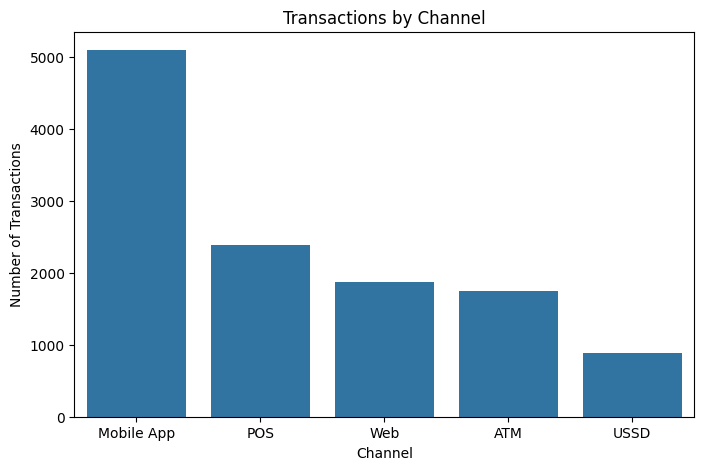

In [15]:
channel_counts = transactions["Channel"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=channel_counts.index,
    y=channel_counts.values
)
plt.title("Transactions by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")
plt.show()

What it shows: The number of transactions completed through each channel.  
Why it matters: Channel usage helps FinTrust understand how customers interact with its banking services.  
Business insight: Mobile App was the most-used channel with 5,102 transactions, followed by POS and Web. This indicates that mobile banking plays a major role in customer activity.

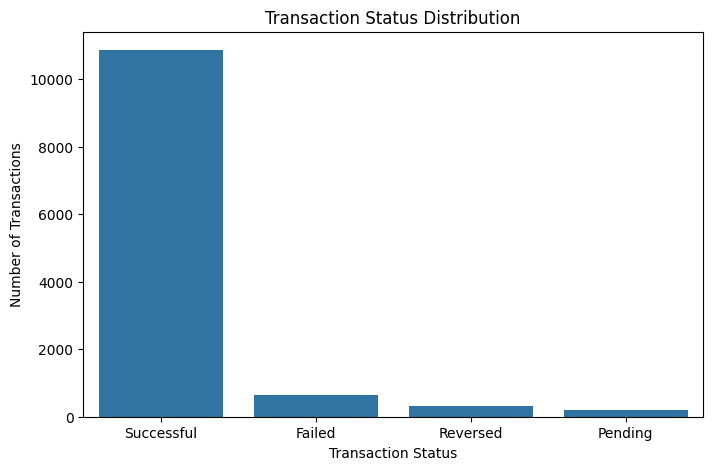

In [16]:
status_counts = transactions["Transaction_Status"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)
plt.title("Transaction Status Distribution")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.show()

What it shows: The distribution of successful, failed, reversed and pending transactions.  
Why it matters: Transaction status is useful for evaluating transaction performance and identifying possible service issues.  
Business insight: Successful transactions accounted for approximately 90.47% of all transactions. Failed, reversed and pending transactions represent a smaller share but remain useful areas for operational monitoring.

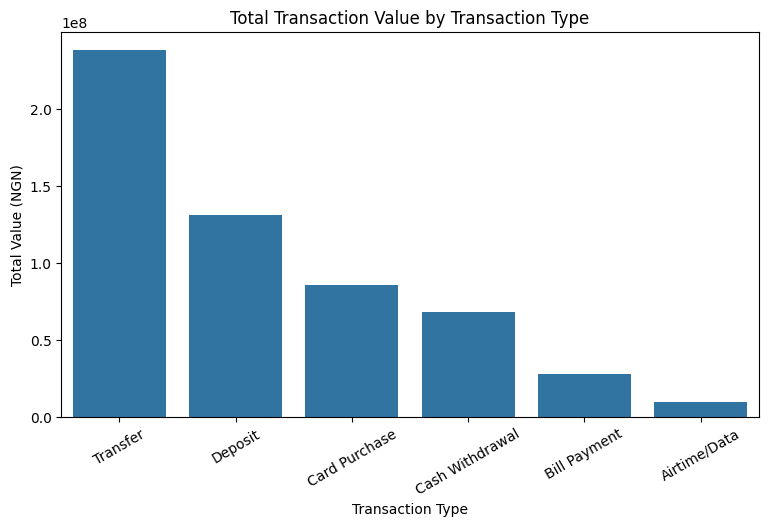

In [17]:
type_value = (
    transactions.groupby("Transaction_Type")["Amount_NGN"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))
sns.barplot(
    x=type_value.index,
    y=type_value.values
)
plt.title("Total Transaction Value by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Total Value (NGN)")
plt.xticks(rotation=30)
plt.show()

What it shows: The total monetary value generated by each transaction type.  
Why it matters: Transaction count alone does not show the financial value associated with different activities.  
Business insight: This comparison helps FinTrust identify which transaction types account for the largest monetary flows and therefore may deserve greater operational attention.

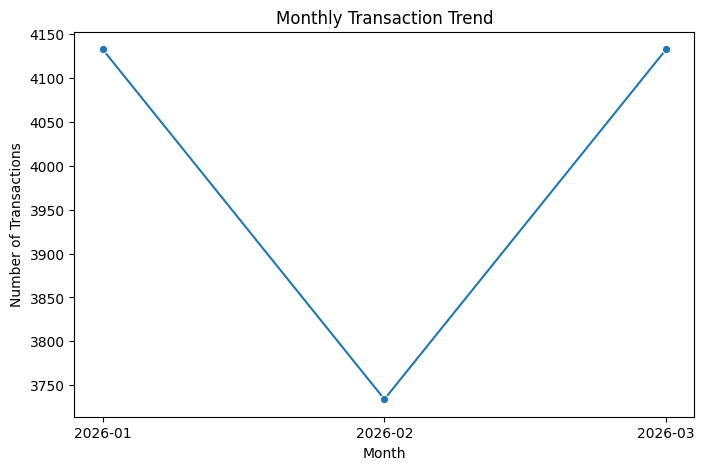

,Month,Transaction_Count
0,2026-01,4133
1,2026-02,3734
2,2026-03,4133


In [18]:
transactions["Month"] = transactions["Transaction_DateTime"].dt.to_period("M").astype(str)

monthly_transactions = (
    transactions.groupby("Month")
    .size()
    .reset_index(name="Transaction_Count")
)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=monthly_transactions,
    x="Month",
    y="Transaction_Count",
    marker="o"
)
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

monthly_transactions

What it shows: How transaction activity changed between January and March 2026.  
Why it matters: Trend analysis helps FinTrust identify changes in transaction activity over time.  
Business insight: Monthly transaction activity can be compared to identify increases, decreases or relatively stable patterns across the three-month period.

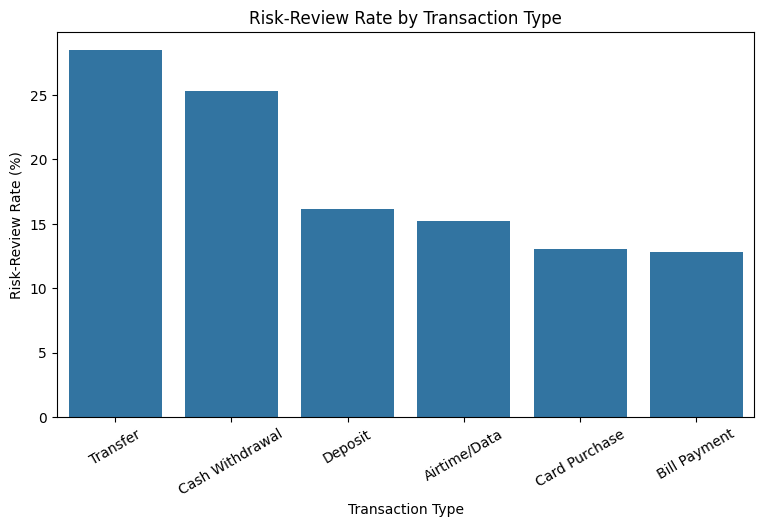

In [19]:
risk_by_type = (
    transactions.groupby("Transaction_Type")["Risk_Review_Flag"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))
sns.barplot(
    x=risk_by_type.index,
    y=risk_by_type.values
)
plt.title("Risk-Review Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Risk-Review Rate (%)")
plt.xticks(rotation=30)
plt.show()

What it shows: The percentage of transactions within each transaction type that were flagged for review.  
Why it matters: Comparing rates rather than raw counts prevents high-volume transaction types from appearing more important simply because they occur more often.  
Business insight: Transaction types with higher review rates may deserve closer investigation. The Risk_Review_Flag is a synthetic educational indicator and should not be interpreted as evidence of fraud.


EDA Summary
The exploratory analysis shows differences in transaction activity across customer segments, channels, transaction types and transaction statuses. Mobile App usage represents a major share of transaction activity, while Everyday customers generate the highest transaction volume. Most transactions are successful, although failed, reversed and pending transactions remain relevant for operational monitoring. Risk-review patterns were also examined as an educational indicator and not as a determination of fraud.
These findings will be used to support the Power BI dashboard and final business recommendations.